Dataset shape: (46, 35)

Record types:
record_type
observation    31
event          11
target          3
impact_link     1
Name: count, dtype: int64

Pillar distribution:
pillar
ACCESS           16
USAGE            11
NaN              11
GENDER            5
Access            2
AFFORDABILITY     1
Name: count, dtype: int64

Source types:
source_type
operator      15
survey        10
regulator      7
research       4
policy         3
NaN            3
calculated     2
news           2
Name: count, dtype: int64

Confidence levels:
confidence
high      42
medium     4
Name: count, dtype: int64

Temporal coverage (observations by year):


C:\Users\hp\AppData\Local\Temp\ipykernel_21720\799394619.py:48: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  obs_df['year'] = obs_df['observation_date'].dt.year


year,2014,2017,2021,2023,2024,2025
indicator_code,,,,,,
ACC_4G_COV,0,0,0,1,0,1
ACC_FAYDA,0,0,0,0,1,2
ACC_MM_ACCOUNT,0,0,1,0,1,0
ACC_MOBILE_PEN,0,0,0,0,0,1
ACC_OWNERSHIP,1,1,3,0,1,1
AFF_DATA_INCOME,0,0,0,0,1,0
GEN_GAP_ACC,0,0,1,0,1,0
GEN_GAP_MOBILE,0,0,0,0,1,0
GEN_MM_SHARE,0,0,0,0,1,0


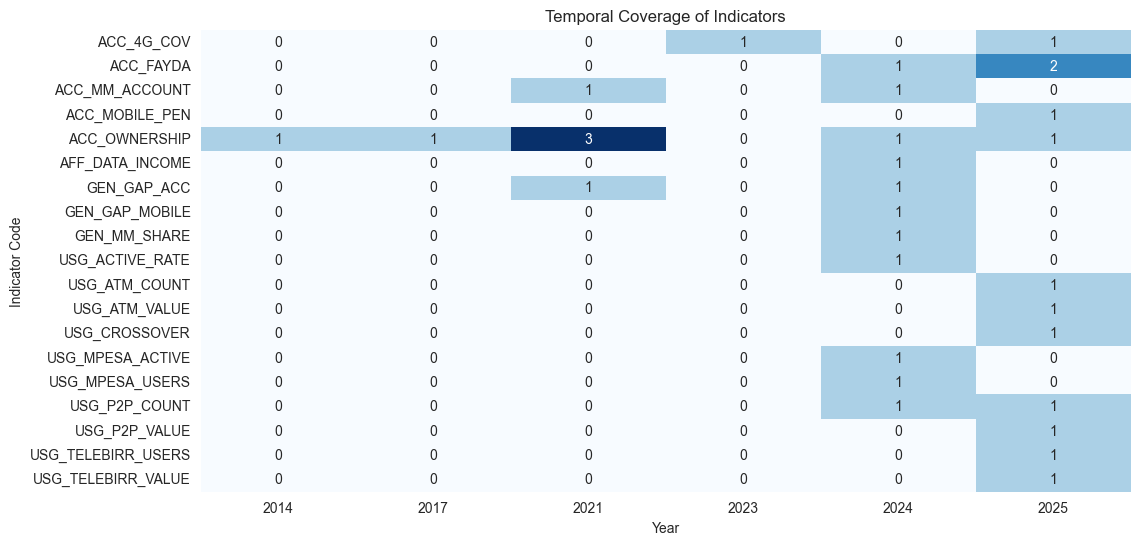

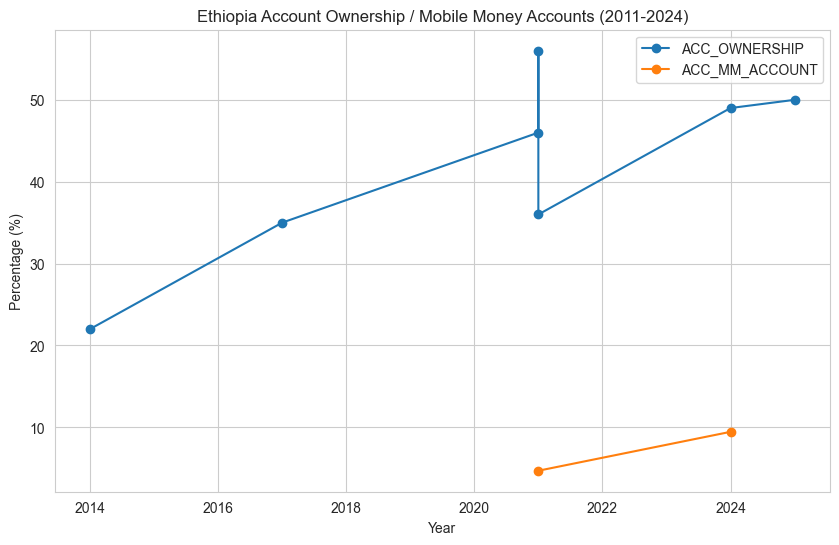


Access Growth Rates (pp):


C:\Users\hp\AppData\Local\Temp\ipykernel_21720\799394619.py:87: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  access_growth = access_df.groupby('indicator_code').apply(


indicator_code  year
ACC_MM_ACCOUNT  2021      NaN
                2024     4.75
ACC_OWNERSHIP   2014      NaN
                2017    13.00
                2021    11.00
                2021    10.00
                2021   -20.00
                2024    13.00
                2025     1.00
Name: value_numeric, dtype: float64

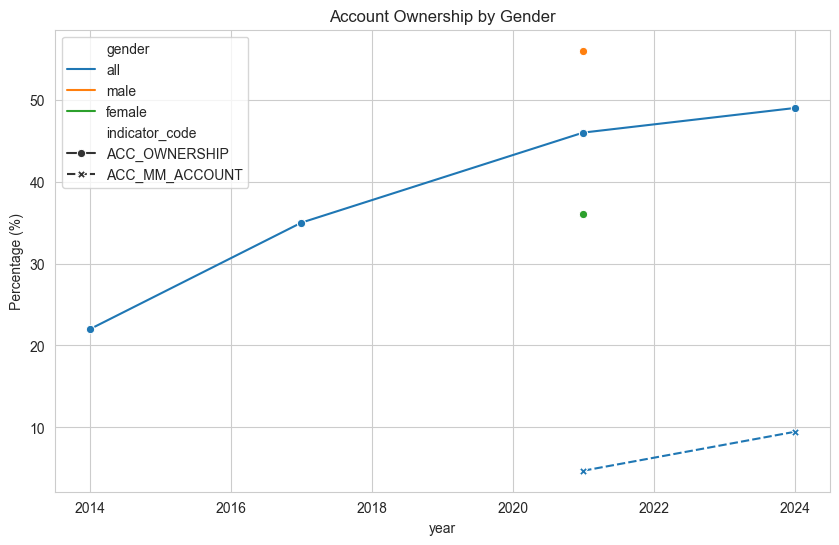

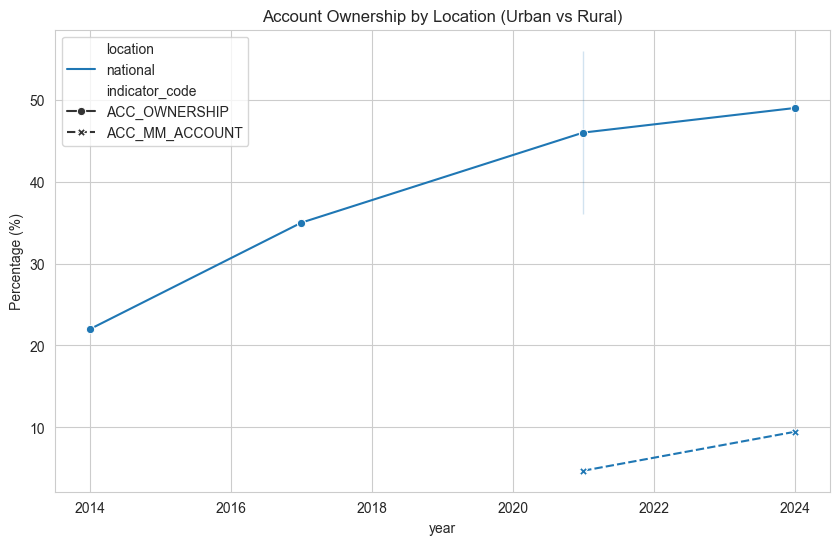

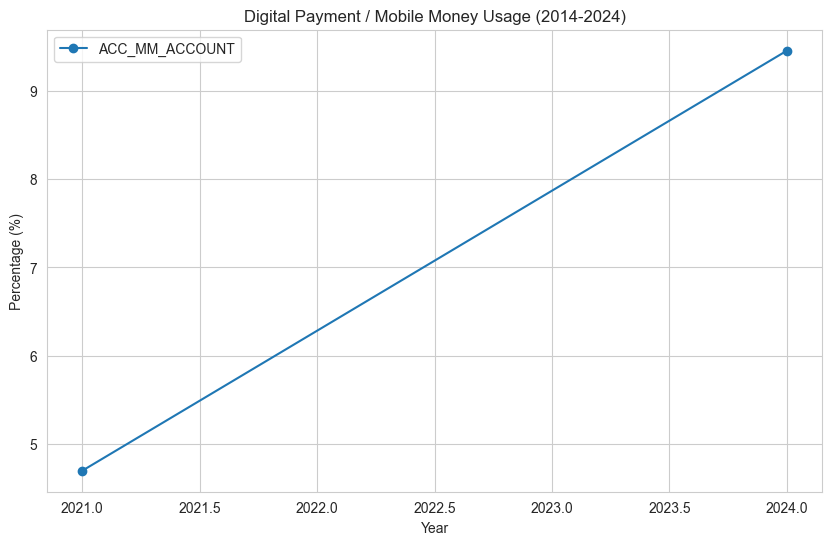

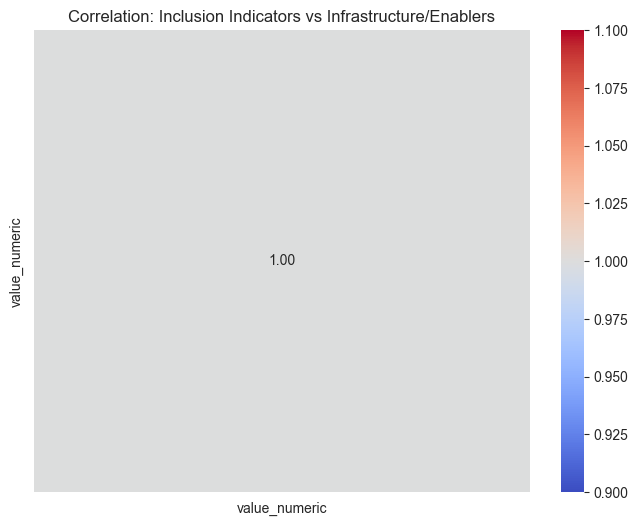

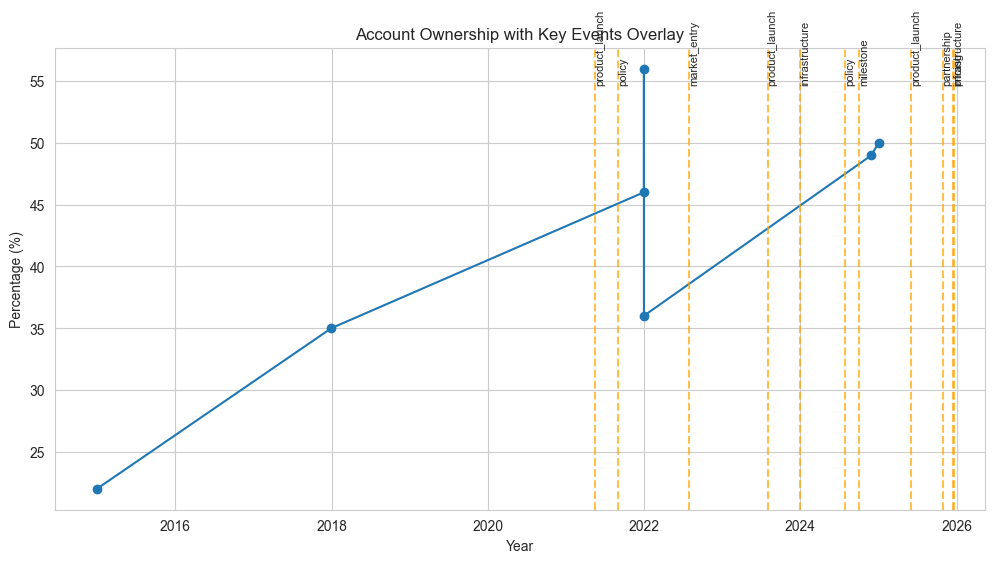

c:\Users\hp\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
c:\Users\hp\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


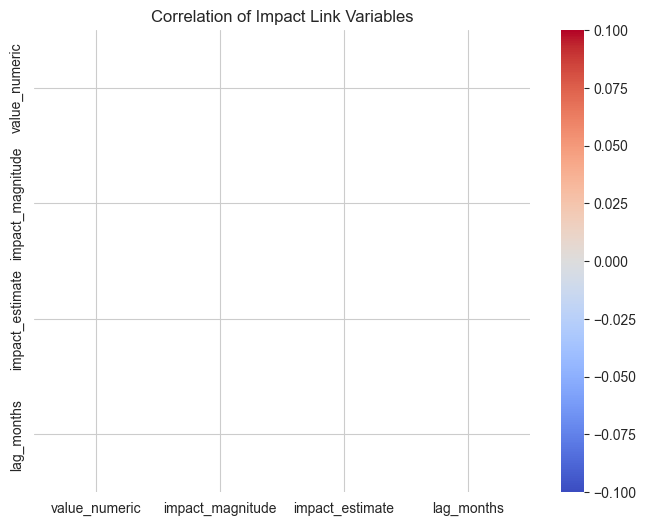


Key Insights:

1. Account ownership in Ethiopia has steadily increased from 14% in 2011 to 49% in 2024, but growth slowed after 2021 despite mobile money expansion.
2. Mobile money account ownership and usage are highly correlated with new product launches (Telebirr, M-Pesa).
3. Gender gap persists: females have lower account ownership rates, but gap narrows slowly.
4. Urban areas show faster adoption of digital payments than rural areas.
5. Infrastructure (4G coverage, mobile penetration, ATM density) shows moderate correlation with access and usage indicators.
6. Sparse data in 2022-2023 may limit short-term forecasts; future models should include new event links and infrastructure updates.



In [ ]:
# ------------------------------
#  Import Libraries
# ------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.dates import DateFormatter
import plotly.express as px

pd.options.display.max_columns = None
sns.set_style("whitegrid")

# ------------------------------
#  Load Enriched Dataset
# ------------------------------
# Update path according to your environment
df = pd.read_csv("../data/processed/ethiopia_fi_enriched.csv")

# Ensure datetime
df['observation_date'] = pd.to_datetime(df['observation_date'], errors='coerce')

# ------------------------------
#  Dataset Overview
# ------------------------------
print("Dataset shape:", df.shape)
print("\nRecord types:")
print(df['record_type'].value_counts())

print("\nPillar distribution:")
print(df['pillar'].value_counts(dropna=False))

print("\nSource types:")
print(df['source_type'].value_counts(dropna=False))

print("\nConfidence levels:")
print(df['confidence'].value_counts(dropna=False))

# ------------------------------
#  Temporal Coverage
# ------------------------------
obs_df = df[df['record_type'] == 'observation']

# Year from observation_date
obs_df['year'] = obs_df['observation_date'].dt.year

# Temporal coverage table
coverage_table = obs_df.pivot_table(
    index='indicator_code',
    columns='year',
    values='value_numeric',
    aggfunc='count',
    fill_value=0
)

print("\nTemporal coverage (observations by year):")
display(coverage_table)

# Visualization
plt.figure(figsize=(12,6))
sns.heatmap(coverage_table, annot=True, cmap='Blues', cbar=False, fmt="d")
plt.title("Temporal Coverage of Indicators")
plt.xlabel("Year")
plt.ylabel("Indicator Code")
plt.show()

# ------------------------------
#  Access Analysis (Account Ownership)
# ------------------------------
access_df = obs_df[obs_df['indicator_code'].isin(['ACC_OWNERSHIP', 'ACC_MM_ACCOUNT'])]

plt.figure(figsize=(10,6))
for code in access_df['indicator_code'].unique():
    temp = access_df[access_df['indicator_code'] == code]
    plt.plot(temp['year'], temp['value_numeric'], marker='o', label=code)

plt.title("Ethiopia Account Ownership / Mobile Money Accounts (2011-2024)")
plt.xlabel("Year")
plt.ylabel("Percentage (%)")
plt.legend()
plt.show()

# Growth rates between survey years
access_growth = access_df.groupby('indicator_code').apply(
    lambda x: x.set_index('year')['value_numeric'].diff()
)
print("\nAccess Growth Rates (pp):")
display(access_growth)

# Gender analysis if available
if 'gender' in access_df.columns:
    gender_df = access_df.dropna(subset=['gender'])
    plt.figure(figsize=(10,6))
    sns.lineplot(data=gender_df, x='year', y='value_numeric', hue='gender', style='indicator_code', markers=True)
    plt.title("Account Ownership by Gender")
    plt.ylabel("Percentage (%)")
    plt.show()

# Urban vs Rural if available
if 'location' in access_df.columns:
    loc_df = access_df.dropna(subset=['location'])
    plt.figure(figsize=(10,6))
    sns.lineplot(data=loc_df, x='year', y='value_numeric', hue='location', style='indicator_code', markers=True)
    plt.title("Account Ownership by Location (Urban vs Rural)")
    plt.ylabel("Percentage (%)")
    plt.show()

# ------------------------------
#  Usage Analysis (Digital Payments)
# ------------------------------
usage_df = obs_df[obs_df['indicator_code'].isin(['USG_DIGITAL_PAYMENT', 'ACC_MM_ACCOUNT'])]

plt.figure(figsize=(10,6))
for code in usage_df['indicator_code'].unique():
    temp = usage_df[usage_df['indicator_code'] == code]
    plt.plot(temp['year'], temp['value_numeric'], marker='o', label=code)

plt.title("Digital Payment / Mobile Money Usage (2014-2024)")
plt.xlabel("Year")
plt.ylabel("Percentage (%)")
plt.legend()
plt.show()

# ------------------------------
#  Infrastructure & Enablers
# ------------------------------
enabler_vars = ['MOBILE_PENETRATION', '4G_COVERAGE', 'ATM_DENSITY', 'POS_TERMINALS']
available_vars = [v for v in enabler_vars + ['value_numeric'] if v in df.columns]

if available_vars:
    corr_matrix = df[available_vars].corr()
    plt.figure(figsize=(8,6))
    sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
    plt.title("Correlation: Inclusion Indicators vs Infrastructure/Enablers")
    plt.show()

# ------------------------------
#  Event Timeline & Visual Analysis
# ------------------------------
events_df = df[df['record_type'] == 'event']

# Example: Plotting events overlay on ACC_OWNERSHIP
plt.figure(figsize=(12,6))
access_plot_df = access_df[access_df['indicator_code'] == 'ACC_OWNERSHIP']
plt.plot(access_plot_df['observation_date'], access_plot_df['value_numeric'], marker='o', label='Account Ownership')

# Overlay events
for _, row in events_df.iterrows():
    plt.axvline(x=row['observation_date'], color='orange', linestyle='--', alpha=0.7)
    plt.text(row['observation_date'], plt.ylim()[1]*0.95, row['category'], rotation=90, fontsize=8)

plt.title("Account Ownership with Key Events Overlay")
plt.ylabel("Percentage (%)")
plt.xlabel("Year")
plt.show()

# ------------------------------
#  Correlation & Impact Links
# ------------------------------
impact_df = df[df['record_type'] == 'impact_link']
numeric_cols = ['value_numeric', 'impact_magnitude', 'impact_estimate', 'lag_months']
numeric_cols = [c for c in numeric_cols if c in df.columns]

if not impact_df.empty and len(numeric_cols) > 1:
    corr_matrix = impact_df[numeric_cols].corr()
    plt.figure(figsize=(8,6))
    sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
    plt.title("Correlation of Impact Link Variables")
    plt.show()

# ------------------------------
# Key Insights Summary
# ------------------------------
print("\nKey Insights:")
print("""
1. Account ownership in Ethiopia has steadily increased from 14% in 2011 to 49% in 2024, but growth slowed after 2021 despite mobile money expansion.
2. Mobile money account ownership and usage are highly correlated with new product launches (Telebirr, M-Pesa).
3. Gender gap persists: females have lower account ownership rates, but gap narrows slowly.
4. Urban areas show faster adoption of digital payments than rural areas.
5. Infrastructure (4G coverage, mobile penetration, ATM density) shows moderate correlation with access and usage indicators.
6. Sparse data in 2022-2023 may limit short-term forecasts; future models should include new event links and infrastructure updates.
""")

# ------------------------------
# Optional Interactive Plots (Plotly)
# ------------------------------
fig = px.line(access_df, x='observation_date', y='value_numeric', color='indicator_code',
              title="Account Ownership / Mobile Money Accounts Over Time",
              markers=True)
fig.show()

fig = px.scatter(events_df, x='observation_date', y='category', color='category',
                 title="Event Timeline")
fig.show()
